<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QForce002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell for dual polarity
import numpy as np
import matplotlib.pyplot as plt

N = 100
epsilon = 0.01
omega = 1.0
x = np.linspace(0, 2*np.pi, N)

# Dual polarity: alternating sinusoidal bands
lattice = epsilon * np.sin(omega * x)
polarity = np.where(np.sin(omega * x) > 0, 1, -1)
charged_lattice = lattice * polarity

history = [charged_lattice.copy()]


In [2]:
# Propagation cell with polarity-aware coupling
def evolve_charged(lattice, polarity, c=1.0, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        interaction = lattice[i+1] - 2*lattice[i] + lattice[i-1]
        new[i] = lattice[i] + c * dt * interaction * polarity[i]
    return new

for t in range(1000):
    charged_lattice = evolve_charged(charged_lattice, polarity)
    if t % 50 == 0:
        history.append(charged_lattice.copy())


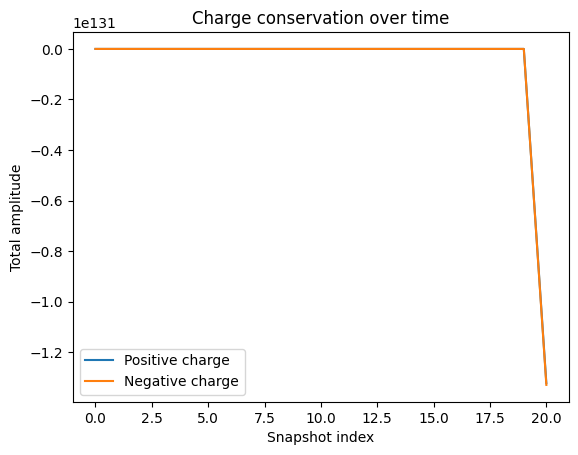

In [3]:
# Charge conservation
pos_charge = [np.sum(h[polarity == 1]) for h in history]
neg_charge = [np.sum(h[polarity == -1]) for h in history]

plt.plot(pos_charge, label="Positive charge")
plt.plot(neg_charge, label="Negative charge")
plt.xlabel("Snapshot index")
plt.ylabel("Total amplitude")
plt.title("Charge conservation over time")
plt.legend()
plt.show()


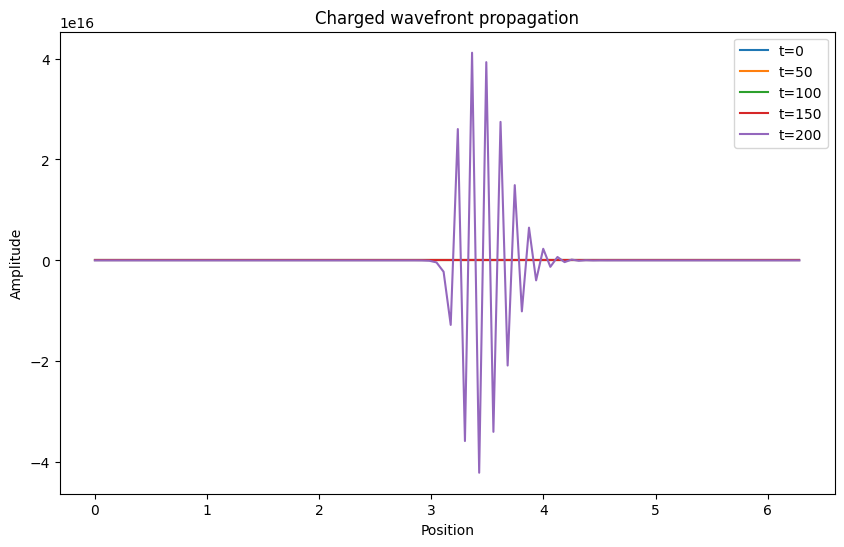

In [4]:
# Wavefront snapshots
plt.figure(figsize=(10,6))
for idx, h in enumerate(history[:5]):
    plt.plot(x, h, label=f"t={idx*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Charged wavefront propagation")
plt.legend()
plt.show()
